# PSO-DN: Particle Swarm Optimisation with Dynamic Strategy

**Reference**: Sun et al., *"A Particle Swarm Optimization with Dynamic Strategy for Multi-modal Multi-objective Location Optimization Problem"*, DOCS 2023.

This notebook provides a self-contained implementation of PSO-DN for Multi-modal Multi-objective Optimization Problems
(MMOPs). The algorithm is demonstrated on a map-based location optimization problem with 4 objectives (minimizing
distance to nearest elementary school, high-school, convenience store, and railway station).

**Notation**: $D$ = dimension, $N$ = population size, $M$ = number of objectives, $K_i$ = number of facilities of type $i$.

## Algorithm Overview

PSO-DN introduces a **dynamic radius strategy** to adaptively partition the swarm into sub-populations. The center solution
(the particle with maximum SCD value in each sub-population) serves as the social guide, replacing the global best of
standard PSO.

**Key steps** (Algorithm 1 in the paper):
1. Initialize population POP, evaluate, initialize PBA (personal best archives) and GBA (global best archive)
2. **Repeat** until stopping criterion:
   - non-dominated sort POP; sort each front by descending SCD
   - compute dynamic neighborhood radius $R$
   - partition POP into sub-populations using $R$
   - for each particle: $\mathbf{v}_i = W\mathbf{v}_i + c_1\mathbf{r}_1(\mathbf{pbest}_i - \mathbf{x}_i) + c_2\mathbf{r}_2(\mathbf{nbest}_i - \mathbf{x}_i)$
   - update position: $\mathbf{x}_i = \mathbf{x}_i + \mathbf{v}_i$
   - evaluate, update PBA and GBA

---
## Imports

In [23]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from pymoo.operators.survival.rank_and_crowding.metrics import calc_crowding_distance
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.indicators.hv import HV
from dataclasses import dataclass, field
from tqdm import tqdm

# Project modules (imported only for problem setup and visualization)
from src.problem import LocationProblem
from data.test_map import facilities, infrastructure, map_styles, x_bounds, v_bounds
from src.plot_utils import plot_city_map_with_solutions

---
## 1. Special Crowding Distance (SCD)

The SCD metric evaluates diversity in both decision space and objective space simultaneously:

$$
\text{SCD}_i = \begin{cases}
\max(\text{CD}_{i,x}, \text{CD}_{i,F}) & \text{if } \text{CD}_{i,x} > \text{CD}_{\text{avg},x} \text{ or } \text{CD}_{i,F} > \text{CD}_{\text{avg},F} \\
\min(\text{CD}_{i,x}, \text{CD}_{i,F}) & \text{otherwise}
\end{cases}
$$

where $\text{CD}_{i,x}$ and $\text{CD}_{i,F}$ are the crowding distances of individual $i$ in decision space and objective space respectively, while $\text{CD}_{\text{avg},x}$ and $\text{CD}_{\text{avg},F}$ are the average crowding distance in decision space and objective space respectively.

In [25]:
def scd_for_front(front_positions, front_fitnesses):
    """
    Compute SCD for all individuals in a single Pareto front.
    
    Parameters
        front_positions: (F, D) array of positions
        front_fitnesses: (F, M) array of fitnesses
    Returns
        scd: (F,) array of SCD values
    """
    #compute CD in both spaces 
    CD_x = calc_crowding_distance(front_positions)
    CD_F = calc_crowding_distance(front_fitnesses)

    # compute average CD (ignoring front extremes with CD=inf)
    finite_CD_x = CD_x[np.isfinite(CD_x)]
    finite_CD_F = CD_F[np.isfinite(CD_F)]
    CD_avg_x = np.mean(finite_CD_x) if len(finite_CD_x) > 0 else 0
    CD_avg_F = np.mean(finite_CD_F) if len(finite_CD_F) > 0 else 0

    # compute SCD
    condition = (CD_x > CD_avg_x) | (CD_F > CD_avg_F)
    scd = np.where(condition, 
                   np.maximum(CD_x, CD_F), 
                   np.minimum(CD_x, CD_F))
    return scd


def get_sorted_fronts_and_scd(positions, fitnesses, nds):
    """
    Non-dominated sort + SCD computation. Returns fronts sorted by SCD descending.
    
    Parameters
        positions: (N, D) array
        fitnesses: (N, M) array
        nds: pymoo NonDominatedSorting instance
    Returns
        sorted_fronts: list of 1D arrays, each front's indices sorted by SCD descending
        global_scd: (N,) array of SCD values
    """
    N = len(positions)
    global_scd = np.zeros(N)

    # non-dominated sorting
    fronts = nds.do(fitnesses)

    sorted_fronts = []
    for front_indices in fronts:
        front_X = positions[front_indices]
        front_F = fitnesses[front_indices]
        scd = scd_for_front(front_X, front_F)
        global_scd[front_indices] = scd
        
        # order front by descending SCD
        order = np.argsort(scd)[::-1]
        sorted_fronts.append(np.array(front_indices)[order])

    return sorted_fronts, global_scd

---
## 2. Archive Data Structure

- **PBA $_i$** (Personal Best Archive): a local memory per particle storing its history of mutually non-dominated solutions.
- **GBA** (Global Best Archive): the overall repository accumulating non-dominated solutions from the entire swarm.

**Dominance update rules**:
1. If the new solution is dominated by any existing entry → discard.
2. If the new solution dominates any existing entries → remove dominated ones, add new solution.
3. If mutually non-dominated → add to archive.

In [26]:
@dataclass
class Archive:
    positions: list = field(default_factory=list)
    fitnesses: list = field(default_factory=list)

    def add_record(self, position: np.ndarray, fitness: np.ndarray):
        """Appends copies of the current position and fitness to the archive."""
        self.positions.append(position.copy())
        self.fitnesses.append(fitness.copy())

    def extract_arrays(self):
        """Converts the internal lists to NumPy arrays and returns them."""
        return np.array(self.positions), np.array(self.fitnesses)

    def update_with_dominance(self, new_positions: np.ndarray, new_fitnesses: np.ndarray, nds: NonDominatedSorting=None) -> None:
        """
        Updates the archive maintaining Pareto dominance.
        Accepts either a single solution (1D array) or a batch of solutions (2D array).
        Assumes a MINIMIZATION problem.
        """
        # normalize inputs so they are always 2D
        new_positions = np.atleast_2d(new_positions)
        new_fitnesses = np.atleast_2d(new_fitnesses)
        num_new = len(new_positions)

        ## single element evaluation
        if num_new == 1 and self.fitnesses:
            current_fit = np.array(self.fitnesses)
            new_fit = new_fitnesses[0]

            # if new solution is dominated
            is_dominated = np.any(
                np.all(current_fit <= new_fit, axis=1) & np.any(current_fit < new_fit, axis=1)
            )
            if is_dominated:
                return 

            # if new solution dominates any existing solutions remove them
            dominates = np.all(new_fit <= current_fit, axis=1) & np.any(new_fit < current_fit, axis=1)
            if np.any(dominates):
                keep_mask = ~dominates  
                current_pos = np.array(self.positions)
                
                self.positions = list(current_pos[keep_mask])
                self.fitnesses = list(current_fit[keep_mask])

            # append the new, non-dominated solution
            self.positions.append(new_positions[0].copy())
            self.fitnesses.append(new_fit.copy())
            return
        
        ## multiple elements (or empty archive)
        if len(self.positions) > 0:
            # if not empty, combine with existing archive
            current_pos, current_fit = self.extract_arrays()
            combined_pos = np.vstack([current_pos, new_positions])
            combined_fit = np.vstack([current_fit, new_fitnesses])
        else:
            # if empty, just evaluate the new batch
            combined_pos = new_positions
            combined_fit = new_fitnesses

        if not nds:
            nds = NonDominatedSorting()
        best_front = nds.do(combined_fit, only_non_dominated_front=True)

        self.positions = list(combined_pos[best_front])
        self.fitnesses = list(combined_fit[best_front])
        
    def remove_similar_solutions(self, decimals: int = 4):
        """
        Removes solutions that are geographically too close (similar positions)
        up to a specified number of decimal places.
        """
        if not self.positions:
            return
        
        pos_arr, _ = self.extract_arrays()

        # find the indices of the unique positions
        _, unique_idx = np.unique(np.round(pos_arr, decimals), axis=0, return_index=True)

        # sort indices to maintain original insertion order
        unique_idx = np.sort(unique_idx)

        self.positions = [self.positions[i] for i in unique_idx]
        self.fitnesses = [self.fitnesses[i] for i in unique_idx]

---
## 3. Fitness Evaluation

Each objective is the Euclidean distance from a candidate location to the nearest facility of a given type:

$$
f_1(\mathbf{x}) = \min_{k_1} \text{dist}(\mathbf{x}, \text{ES}_{k_1}), \quad
f_2(\mathbf{x}) = \min_{k_2} \text{dist}(\mathbf{x}, \text{HS}_{k_2}), \quad
f_3(\mathbf{x}) = \min_{k_3} \text{dist}(\mathbf{x}, \text{CS}_{k_3}), \quad
f_4(\mathbf{x}) = \min_{k_4} \text{dist}(\mathbf{x}, \text{RS}_{k_4})
$$

where ES = elementary schools, HS = high-schools, CS = convenience stores, RS = railway stations.

In [27]:
def evaluate_population(pop, facilities):
    """
    Vectorized fitness evaluation for an entire population.
    
    Parameters
        pop: (N, D) position matrix
        facilities: dict of {name: (K_i, D) array} for each facility type
    Returns
        (N, M) fitness matrix
    """
    fitness_scores = []
    
    # ensure the objectives order is always consistent
    facility_keys = sorted(facilities.keys())

    for key in facility_keys:
        # euclidean distance from every individual to every facility of type key
        dist_matrix = distance.cdist(pop, facilities[key], metric='euclidean')
        nearest_distances = dist_matrix.min(axis=1)
        fitness_scores.append(nearest_distances)
    
    # fitness_score is a list of M arrays of size N
    # stack the list into an (N, M) matrix
    return np.column_stack(fitness_scores)

---
## 4. PSO Velocity and Position Updates

The PSO-DN velocity update replaces the global best with the sub-population center (nbest):

$$
\mathbf{v}_i(t) = W \cdot \mathbf{v}_i(t-1) + c_1\mathbf{r}_1(\mathbf{pbest}_i - \mathbf{x}_i(t)) + c_2\mathbf{r}_2(\mathbf{nbest}_i - \mathbf{x}_i(t))
$$

Position update follows the standard PSO rule:

$$
\mathbf{x}_i(t) = \mathbf{x}_i(t-1) + \mathbf{v}_i(t)
$$

Boundary violations are handled by clamping positions and reflecting/damping velocities.

In [28]:
def update_velocity_dn(positions, velocities, nbest, pbest, v_bounds, v_params):
    """
    Vectorized PSO-DN velocity update.
    
    Parameters
        positions: (N, D) current positions
        velocities: (N, D) current velocities
        nbest: (N, D) sub-population centers
        pbest: (N, D) personal best positions
        v_bounds: (D, 2) velocity bounds [min, max] per dimension
        v_params: tuple (w, c1, c2)
    Returns
        new_velocities: (N, D) updated velocities
    """
    w, c1, c2 = v_params
    N, D = positions.shape
    r1, r2 = np.random.random((N, D)), np.random.random((N, D))

    inertia = w * velocities
    cognitive = c1 * r1 * (pbest - positions)
    social = c2 * r2 * (nbest - positions)

    new_velocities = inertia + cognitive + social

    v_min, v_max = v_bounds[:, 0], v_bounds[:, 1]
    magnitudes = np.abs(new_velocities)
    signs = np.sign(new_velocities)
    return signs * np.clip(magnitudes, v_min, v_max)


def update_position_dn(positions, velocities, x_bounds):
    """
    Vectorized position update with damping boundary enforcement.
    
    Parameters
        positions: (N, D) current positions
        velocities: (N, D) current velocities (modified in-place for boundary damping)
        x_bounds: (D, 2) position bounds [min, max] per dimension
    Returns
        new_positions: (N, D) clamped positions
        velocities: (N, D) post-damping velocities
    """
    new_positions = positions + velocities

    x_min, x_max = x_bounds[:, 0], x_bounds[:, 1]
    violations = (new_positions < x_min) | (new_positions > x_max)
    new_positions = np.clip(new_positions, x_min, x_max)

    # dampen and reverse velocities where boundaries were hit
    velocities[violations] *= -np.random.random(positions.shape)[violations]
    return new_positions, velocities

---
## 5. Dynamic Radius Strategy

The dynamic radius preserves diversity by adjusting the neighborhood size based on the swarm's spatial distribution:

1. count neighbors within $R_l$ for each particle
2. identify the particle with the **most** neighbors → compute its closest neighbor distance $d_h$
3. identify the non-dominated particle with the **fewest** neighbors → compute its closest neighbor distance $d_s$
4. if $d_h < d_s$ (high density detected): set $R_u = \text{distance}(\text{idx}_{\max}, \text{idx}_{\min,\text{nd}})$
5. otherwise: keep $R = R_l$.

In [29]:
def get_dynamic_radius(dist_matrix, R_l, non_dom_indices):
    """
    Dynamic radius setting strategy.
    
    Parameters
        dist_matrix: (N, N) pairwise Euclidean distance matrix
        R_l: float, initial predefined radius
        non_dom_indices: 1D array of indices of non-dominated solutions
    Returns
        updated radius (float): either R_l or the distance between two reference individuals
    """
    # number of neighbors within R_l for every individual
    neighbors_count = np.sum(dist_matrix <= R_l, axis=1) - 1

    # find the two reference individuals
    idx_max = np.argmax(neighbors_count)
    nd_counts = neighbors_count[non_dom_indices]
    local_idx_min = np.argmin(nd_counts)
    idx_min_nd = non_dom_indices[local_idx_min]

    np.fill_diagonal(dist_matrix, np.inf)
    d_h = np.min(dist_matrix[idx_max])
    d_s = np.min(dist_matrix[idx_min_nd])
    np.fill_diagonal(dist_matrix, 0.0)

    if d_h < d_s:
        return dist_matrix[idx_max, idx_min_nd]
    else:
        return R_l

---
## 6. Sub-population Assignment

Particles are grouped into sub-populations via a greedy niching procedure. We iterate through all
particles in descending SCD order; for each unassigned particle, we form a new sub-population
consisting of all unassigned particles within the current radius $R$. The seed particle becomes
the **nbest** (center solution) for that sub-population.

In [30]:
def assign_subpopulations(dist_matrix, current_radius, sorted_fronts):
    """
    Greedy niching: assign particles to sub-populations by SCD-descending order.
    
    Parameters
        dist_matrix: (N, N) pairwise distance matrix
        current_radius: float, the neighborhood radius
        sorted_fronts: list of 1D arrays, each front sorted by SCD descending
    Returns
        sub_populations: (N,) array of sub-population IDs (-1 = unassigned)
        nbest_indices: (N,) array of nbest particle indices for each particle
    """
    N = dist_matrix.shape[0]
    sub_populations = np.full(N, -1)
    nbest_indices = np.full(N, -1)

    sorted_indices = np.concatenate(sorted_fronts)
    n_subpops = 0

    for idx in sorted_indices:
        if sub_populations[idx] == -1:  # if not yet assigned

            # find all unassigned particles within radius
            in_radius = dist_matrix[idx] <= current_radius
            unassigned = sub_populations == -1

            sub_populations[in_radius & unassigned] = n_subpops
            nbest_indices[in_radius & unassigned] = idx
            n_subpops += 1

    return sub_populations, nbest_indices

---
## 7. nbest and pbest Selection

- **nbest**: the center solution (maximum SCD) of each sub-population, derived from the dynamic radius + greedy niching.
- **pbest**: the solution with maximum SCD value from each particle's personal best archive PBA $_i$.

In [31]:
def get_nbest(positions, R_l, sorted_fronts):
    """
    Compute nbest via dynamic radius + sub-population assignment.
    
    Parameters
        positions: (N, D) current positions
        R_l: float, initial radius
        sorted_fronts: list of 1D arrays from get_sorted_fronts_and_scd
    Returns
        (N, D) array of nbest positions for each particle
    """
    dist_matrix = distance.cdist(positions, positions, metric='euclidean')
    current_radius = get_dynamic_radius(dist_matrix, R_l, sorted_fronts[0])
    _, nbest_idx = assign_subpopulations(dist_matrix, current_radius, sorted_fronts)
    return positions[nbest_idx]


def get_pbest(pba_archives):
    """
    Select pbest as the max-SCD solution from each PBA.
    
    Parameters
        pba_archives: list of N Archive objects
    Returns
        (N, D) array of pbest positions
    """
    pbest = []
    for pba_i in pba_archives:
        positions, fitnesses = pba_i.extract_arrays()
        scd = scd_for_front(positions, fitnesses)
        pbest.append(positions[np.argmax(scd)])
    return np.array(pbest)

---
## 8. Archive Update Procedure

Each particle's PBA is updated with its latest position via dominance check. The GBA is updated
by combining its current contents with the full population and extracting the non-dominated front.

In [32]:
def update_archives_dn(pba_archives, gba_archive, positions, fitnesses, nds):
    """Update personal best archives and global best archive."""
    for i in range(len(positions)):
        pba_archives[i].update_with_dominance(positions[i], fitnesses[i])

    gba_archive.update_with_dominance(positions,fitnesses,nds)

---
## 9. Complete PSO-DN Algorithm

The main loop orchestrates: initialization, non-dominated sorting, SCD computation, dynamic radius,
sub-population assignment, velocity/position updates, and archive maintenance.

In [33]:
def pso_dn(swarm_size, x_bounds, v_bounds, n_iter, facilities, R_l, v_params):
    """
    PSO-DN main optimization loop (Algorithm 1).
    
    Parameters
        swarm_size: int, population size N
        x_bounds: (D, 2) position bounds
        v_bounds: (D, 2) velocity bounds
        n_iter: int, number of iterations
        facilities: dict passed to evaluate_population
        R_l: float, initial radius
        v_params: tuple (w, c1, c2)
    Returns
        gba_archive: Archive containing the global Pareto front
        hist: list of population position arrays per iteration
    """
    D = len(x_bounds)
    x_bounds = np.asarray(x_bounds)
    v_bounds = np.asarray(v_bounds)

    nds = NonDominatedSorting()

    # Initialize population (positions and velocities)
    positions = np.random.uniform(x_bounds[:, 0], x_bounds[:, 1], size=(swarm_size, D))
    # signs = np.random.choice([-1, 1], size=(swarm_size, D))
    # magnitudes = np.random.uniform(v_bounds[:, 0], v_bounds[:, 1], size=(swarm_size, D))
    # velocities = signs * magnitudes
    velocities = np.zeros((swarm_size, D))

    # Evaluate initial population
    fitnesses = evaluate_population(positions, facilities)

    # Initialize personal best archives
    pba_archives = [
        Archive(positions=[positions[i].copy()], fitnesses=[fitnesses[i].copy()])
        for i in range(swarm_size)
    ]

    # Initialize global best archive
    gba_archive = Archive()
    gba_archive.update_with_dominance(positions,fitnesses,nds)

    hist = [positions.copy()]

    # Main loop
    for i in tqdm(range(n_iter), desc="Running PSO-DN"):
        sorted_fronts, _ = get_sorted_fronts_and_scd(positions, fitnesses, nds)
        nbest = get_nbest(positions, R_l, sorted_fronts)
        pbest = get_pbest(pba_archives)

        velocities = update_velocity_dn(positions, velocities, nbest, pbest, v_bounds, v_params)
        positions, velocities = update_position_dn(positions, velocities, x_bounds)
        
        fitnesses = evaluate_population(positions, facilities)

        update_archives_dn(pba_archives, gba_archive, positions, fitnesses, nds)
        hist.append(positions.copy())

        if i % 20 == 1:
            gba_archive.remove_similar_solutions()

    gba_archive.remove_similar_solutions()
    return gba_archive, hist

---
## 10. Experimental Results

We set up the map-based location optimization problem and run PSO-DN with the following parameters,
consistent with the paper's experimental setup.

**Parameters**: $N = 100$, $\text{iterations} = 500$, $R_l = 7.0$, $W = 0.8$, $c_1 = c_2 = 1.49445$.

In [57]:
# Problem parameters
D = 2
M = 4
K = [6, 3, 13, 3]

# PSO-DN parameters
N = 200
n_iter = 50
R_l = 8.0
w = 0.729
c1 = 1.49445
c2 = 1.49445

np.random.seed(119)

# Initialize the location problem
problem = LocationProblem(
    D=D, M=M, K=K,
    facilities=facilities,
    infrastructure=infrastructure,
    map_styles=map_styles,
    x_bounds=x_bounds
)

In [58]:
best, hist = pso_dn(N, x_bounds, v_bounds, n_iter, facilities, R_l, (w, c1, c2))

Running PSO-DN: 100%|██████████| 50/50 [00:02<00:00, 22.84it/s]


### Results: Final Pareto Front

The scatter plot shows the optimal locations found by PSO-DN (cyan circles) overlaid on the city map.
Three distinct Pareto-optimal regions are visible, corresponding to the problem's multi-modality.

PSO-DN found 834 Pareto-optimal solutions


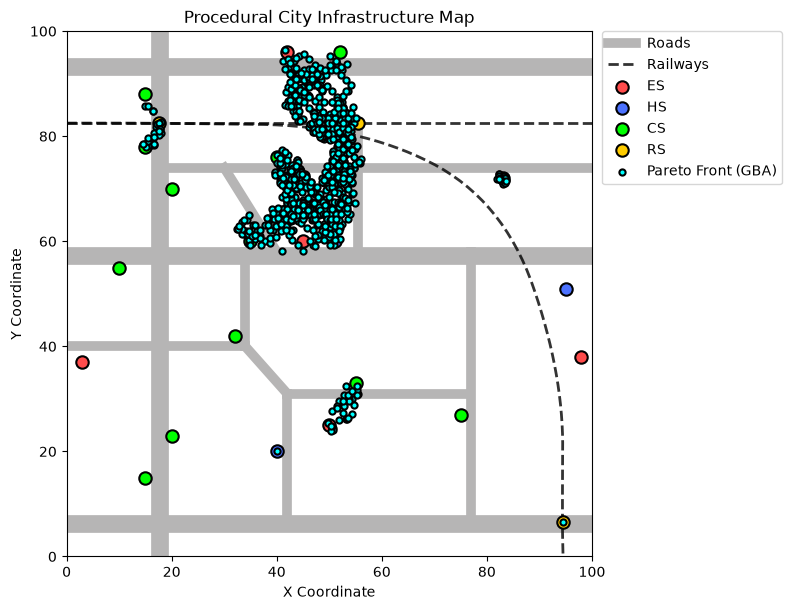

In [61]:
best_positions, best_fitnesses = best.extract_arrays()
ref2 = np.array([200,200,200,200])
ref4 = np.array([400,400,400,400])
hv2 = HV(ref_point=ref2)
hv4 = HV(ref_point=ref4)

print(f"PSO-DN found {len(best_positions)} Pareto-optimal solutions")

plot_city_map_with_solutions(
    facilities, infrastructure, map_styles,
    best_positions,
    label="Pareto Front (GBA)",
    color="#00ffff", marker="o", size=20
)

### Population Dynamics

The initial population (randomly scattered) converges toward the three Pareto regions over time.

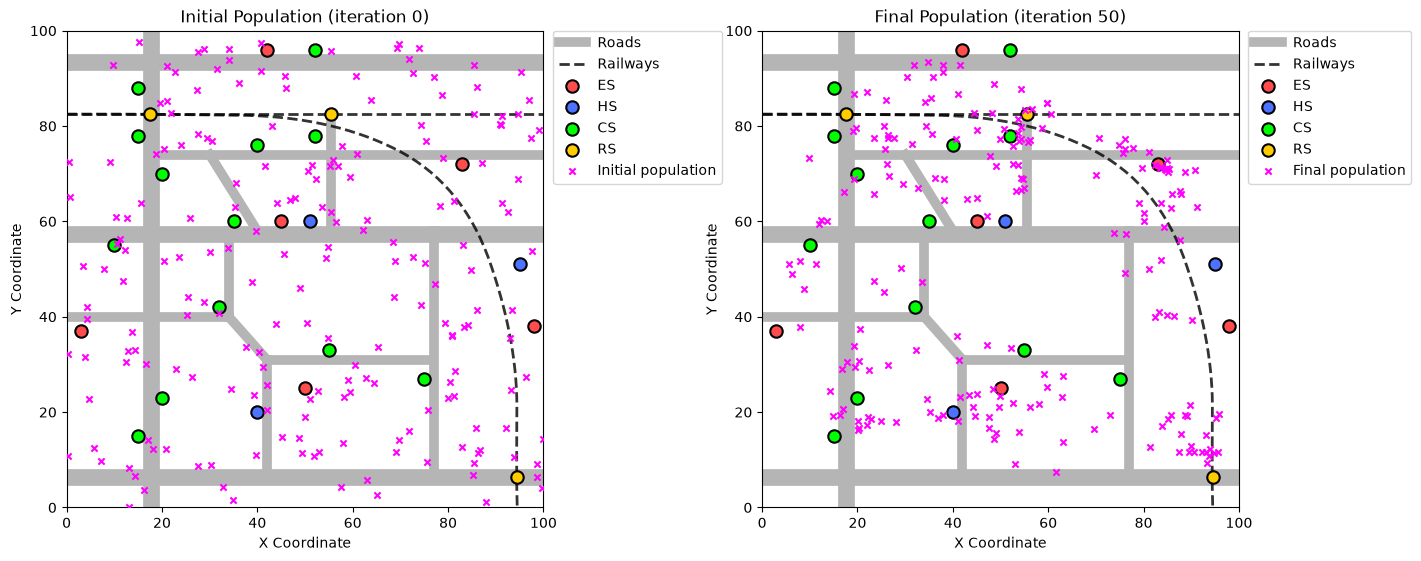

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_city_map_with_solutions(
    facilities, infrastructure, map_styles,
    hist[0], label="Initial population",
    color="#ff00ff", marker="x", size=20, ax=ax1
)
ax1.set_title("Initial Population (iteration 0)")

plot_city_map_with_solutions(
    facilities, infrastructure, map_styles,
    hist[-1], label="Final population",
    color="#ff00ff", marker="x", size=20, ax=ax2
)
ax2.set_title(f"Final Population (iteration {n_iter})")

plt.tight_layout()
plt.show()